In [1]:
import pandas as pd

dados = pd.read_excel('dados.xlsx', sheet_name = 'GEE Estados')

dados_apenas_emissao = dados[dados['Emissão / Remoção / Bunker'] == 'Emissão'].drop(columns='Emissão / Remoção / Bunker')

c:\Users\leoka\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [2]:
colunas_info = list(dados_apenas_emissao.loc[:, 'Nível 1 - Setor': 'Produto'].columns)

anos_info = list(list(dados_apenas_emissao.loc[:, 1970: 2021].columns))

In [3]:
emissoes_por_ano = dados_apenas_emissao.melt(id_vars=colunas_info, value_vars=anos_info, var_name='Ano', value_name='Emissao')

In [4]:
emissoes_por_ano.groupby('Gás').get_group('C2F6 (t)')

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Ano,Emissao
410,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Soderberg,NaN,NaN,C2F6 (t),BA,MET,ALU,1970,0.000000
411,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Soderberg,NaN,NaN,C2F6 (t),MG,MET,ALU,1970,0.820978
412,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Soderberg,NaN,NaN,C2F6 (t),SP,MET,ALU,1970,0.574684
425,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Prebaked Anode,NaN,NaN,C2F6 (t),PA,MET,ALU,1970,0.000000
426,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Prebaked Anode,NaN,NaN,C2F6 (t),MA,MET,ALU,1970,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4832559,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Soderberg,NaN,NaN,C2F6 (t),MG,MET,ALU,2021,0.000000
4832560,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Soderberg,NaN,NaN,C2F6 (t),SP,MET,ALU,2021,2.424895
4832573,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Prebaked Anode,NaN,NaN,C2F6 (t),PA,MET,ALU,2021,0.789007
4832574,Processos Industriais,Produção de Metais,Produção de Alumínio,Tecnologia Prebaked Anode,NaN,NaN,C2F6 (t),MA,MET,ALU,2021,0.000000


In [5]:
#emissoes_por_ano.groupby('Gás').sum(numeric_only=True)
emissao_por_gas = emissoes_por_ano.groupby('Gás')[['Emissao']].sum(numeric_only=True).sort_values('Emissao', ascending=False)

emissao_por_gas

,Emissao
Gás,
CO2e (t) GWP-AR5,8.181375e+10
CO2e (t) GWP-AR6,8.132316e+10
CO2e (t) GWP-AR4,8.015921e+10
CO2e (t) GWP-AR2,7.720596e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR6,6.247859e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2 (t),5.324636e+10


<Axes: ylabel='Gás'>

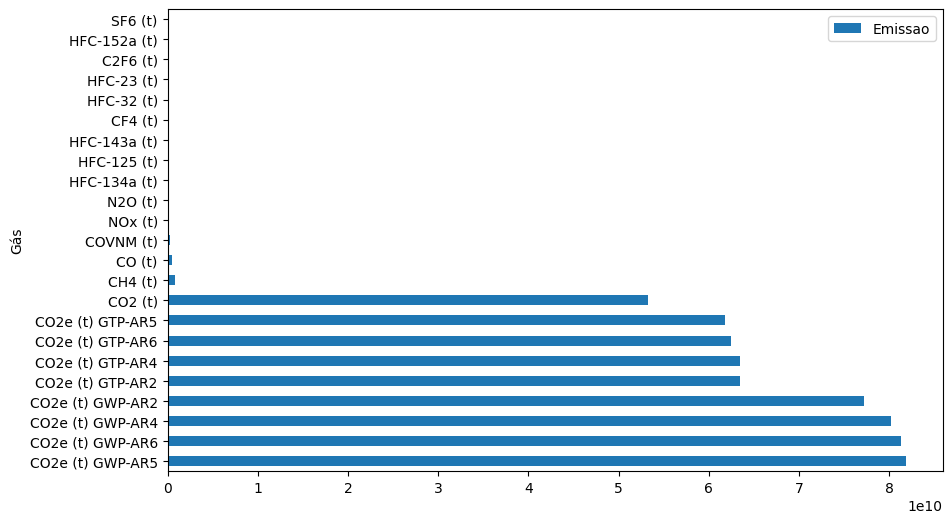

In [6]:
emissao_por_gas.plot(kind='barh', figsize=(10,6))

In [7]:
emissao_por_gas.iloc[0:9]

,Emissao
Gás,
CO2e (t) GWP-AR5,8.181375e+10
CO2e (t) GWP-AR6,8.132316e+10
CO2e (t) GWP-AR4,8.015921e+10
CO2e (t) GWP-AR2,7.720596e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR6,6.247859e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2 (t),5.324636e+10


In [8]:
print(f'A emissão de CO2 corresponde a {float((emissao_por_gas.iloc[0:9].sum()/emissao_por_gas.sum()).iloc[0])*100:.2f}% de emissão total de gases estufa no Brasil de 1970 a 2021.')

A emissão de CO2 corresponde a 99.74% de emissão total de gases estufa no Brasil de 1970 a 2021.
